# Introducción.

El objetivo de este cuaderno es poder segmentar usuarios mediante clústeres basados en Kmeans y Análisis de Componentes principales a partir de datos obtenidos de distintas fuentes de datos.

## Paso 1.

Instalar e importar las librerías y métodos necesarios.

Desde la terminal instalamos movecolumn:

pip install movecolumn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import movecolumn as mc
import seaborn as sb
import plotly.express as px
import openpyxl


from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")

## Paso 2.

Cargar ficheros a la carpeta de trabajo.

## Paso 3.

Crear dos DataFrames a partir de los ficheros cargados.

In [3]:
# Creamos dos DataFrames de Pandas con los dos ficheros cargados

df1 = pd.read_csv('DatosCSVSegmentacion.csv', sep=',')
df1.info()
df2 = pd.read_excel('DatosExcelSegmentación.xlsx', sheet_name='default_1')
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Account Length  3333 non-null   int64
 1   Churn           3333 non-null   int64
 2   Int'l Plan      3333 non-null   int64
 3   VMail Plan      3333 non-null   int64
 4   State           3333 non-null   str  
 5   Area Code       3333 non-null   int64
 6   Phone           3333 non-null   str  
dtypes: int64(5), str(2)
memory usage: 182.4 KB
<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   VMail Message   3333 non-null   int64  
 1   Day Mins        3333 non-null   float64
 2   Eve Mins        3333 non-null   float64
 3   Night Mins      3333 non-null   float64
 4   Intl Mins       3333 non-null   float64
 5   CustServ Calls  3333 non-null   int64  
 6   Day Calls

## Paso 4.

Renombramos los nombres de las features de ambos DataFrames para que no contengan espacios ni apóstrofes en el nombre

In [4]:
df1r = df1.rename(columns={"Account Length":"Account_Length", "Int'l Plan":"Intl_Plan", "VMail Plan":"VMail_Plan", "Area Code":"Area_Code"})
df2r = df2.rename(columns={"VMail Message":"VMail_Message", "Day Mins":"Day_Mins", "Eve Mins":"Eve_Mins", "Night Mins":"Night_Mins", "Intl Mins":"Intl_Mins", "CustServ Calls":"CustServ_Calls", "Day Calls":"Day_Calls", "Day Charge":"Day_Charge", "Eve Calls":"Eve_Calls", "Eve Charge":"Eve_Charge", "Night Calls":"Night_Calls", "Night Charge":"Night_Charge", "Intl Calls":"Intl_Calls", "Intl Charge":"Intl_Charge", "Area Code":"Area_Code" })

print(df1r)
print(df2r)

      Account_Length  Churn  Intl_Plan  VMail_Plan State  Area_Code     Phone
0                128      0          0           1    KS        415  382-4657
1                107      0          0           1    OH        415  371-7191
2                137      0          0           0    NJ        415  358-1921
3                 84      0          1           0    OH        408  375-9999
4                 75      0          1           0    OK        415  330-6626
...              ...    ...        ...         ...   ...        ...       ...
3328             192      0          0           1    AZ        415  414-4276
3329              68      0          0           0    WV        415  370-3271
3330              28      0          0           0    RI        510  328-8230
3331             184      0          1           0    CT        510  364-6381
3332              74      0          0           1    TN        415  400-4344

[3333 rows x 7 columns]
      VMail_Message  Day_Mins  Eve_Mins

## Paso 5.

Corregimos el formato de la feature Area_Code del DataFrame df2r de float64 a int64

In [5]:
df2r['Area_Code'] =df2r['Area_Code'].astype(int)
print(df2r)

      VMail_Message  Day_Mins  Eve_Mins  Night_Mins  Intl_Mins  \
0                25     265.1     197.4       244.7       10.0   
1                26     161.6     195.5       254.4       13.7   
2                 0     243.4     121.2       162.6       12.2   
3                 0     299.4      61.9       196.9        6.6   
4                 0     166.7     148.3       186.9       10.1   
...             ...       ...       ...         ...        ...   
3328             36     156.2     215.5       279.1        9.9   
3329              0     231.1     153.4       191.3        9.6   
3330              0     180.8     288.8       191.9       14.1   
3331              0     213.8     159.6       139.2        5.0   
3332             25     234.4     265.9       241.4       13.7   

      CustServ_Calls  Day_Calls  Day_Charge  Eve_Calls  Eve_Charge  \
0                  1        110       45.07         99       16.78   
1                  1        123       27.47        103       16.62 

## Paso 6.

Uniremos los dos dataframes utilizando como guía las features Area_Code y Phone, que son comunes en ambos DataFrames y realizaremios un análisis exploratorio del dataframe resultante.

In [6]:
dfw = pd.merge(df2r, df1r, on=('Area_Code', 'Phone'), how='inner')
dfw['Charge'] = dfw['Day_Charge']+dfw['Eve_Charge']+dfw['Night_Charge']+dfw['Intl_Charge']
dfw = mc.MoveToLast(dfw,'Area_Code')
dfw = mc.MoveToLast(dfw,'Phone')
dfw['Area_Code'] =dfw['Area_Code'].astype(str)
dfw

,VMail_Message,Day_Mins,Eve_Mins,Night_Mins,Intl_Mins,CustServ_Calls,Day_Calls,Day_Charge,Eve_Calls,Eve_Charge,...,Intl_Calls,Intl_Charge,Account_Length,Churn,Intl_Plan,VMail_Plan,State,Charge,Area_Code,Phone
0,25,265.1,197.4,244.7,10.0,1,110,45.07,99,16.78,...,3,2.70,128,0,0,1,KS,75.56,415,382-4657
1,26,161.6,195.5,254.4,13.7,1,123,27.47,103,16.62,...,3,3.70,107,0,0,1,OH,59.24,415,371-7191
2,0,243.4,121.2,162.6,12.2,0,114,41.38,110,10.30,...,5,3.29,137,0,0,0,NJ,62.29,415,358-1921
3,0,299.4,61.9,196.9,6.6,2,71,50.90,88,5.26,...,7,1.78,84,0,1,0,OH,66.80,408,375-9999
4,0,166.7,148.3,186.9,10.1,3,113,28.34,122,12.61,...,3,2.73,75,0,1,0,OK,52.09,415,330-6626
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,36,156.2,215.5,279.1,9.9,2,77,26.55,126,18.32,...,6,2.67,192,0,0,1,AZ,60.10,415,414-4276
3329,0,231.1,153.4,191.3,9.6,3,57,39.29,55,13.04,...,4,2.59,68,0,0,0,WV,63.53,415,370-3271
3330,0,180.8,288.8,191.9,14.1,2,109,30.74,58,24.55,...,6,3.81,28,0,0,0,RI,67.74,510,328-8230
3331,0,213.8,159.6,139.2,5.0,2,105,36.35,84,13.57,...,10,1.35,184,0,1,0,CT,57.53,510,364-6381


In [7]:
dfw.groupby('Churn').describe().T

Churn                          0           1
VMail_Message count  2850.000000  483.000000
              mean      8.604561    5.115942
              std      13.913125   11.860138
              min       0.000000    0.000000
              25%       0.000000    0.000000
...                          ...         ...
Charge        min      23.250000   22.930000
              25%      52.220000   53.425000
              50%      58.920000   66.910000
              75%      65.137500   76.655000
              max      87.290000   96.150000

[144 rows x 2 columns]

<Axes: >

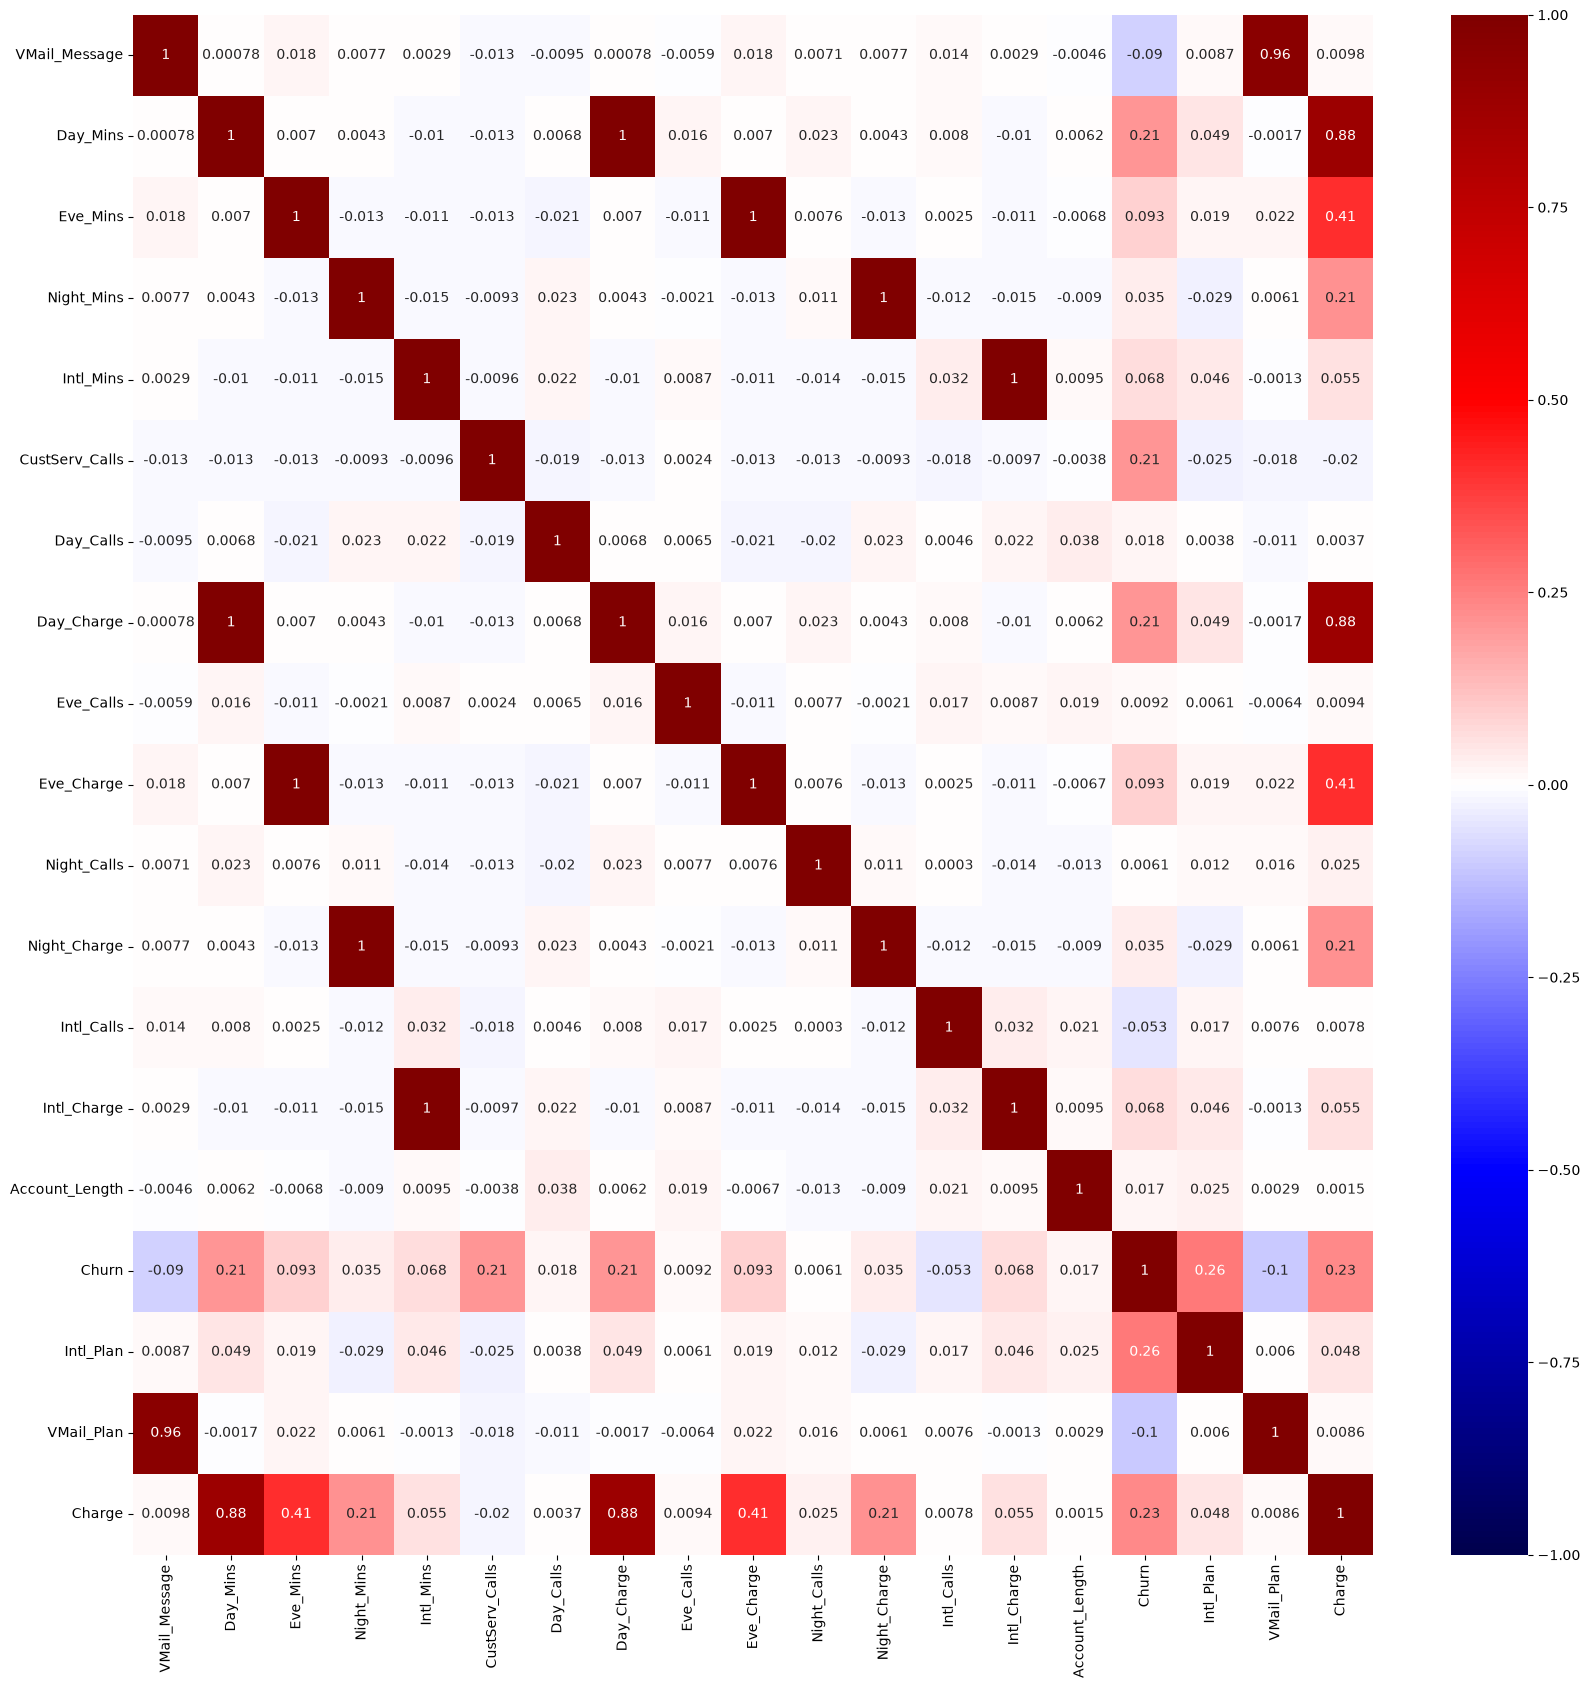

In [8]:
dfw_num = dfw.select_dtypes(include="number")
corr = dfw_num.corr()

fig, ax = plt.subplots(figsize=(20,20))
sb.heatmap(corr, cmap="seismic", center=0, vmin=-1, vmax=1, annot=True, ax=ax)

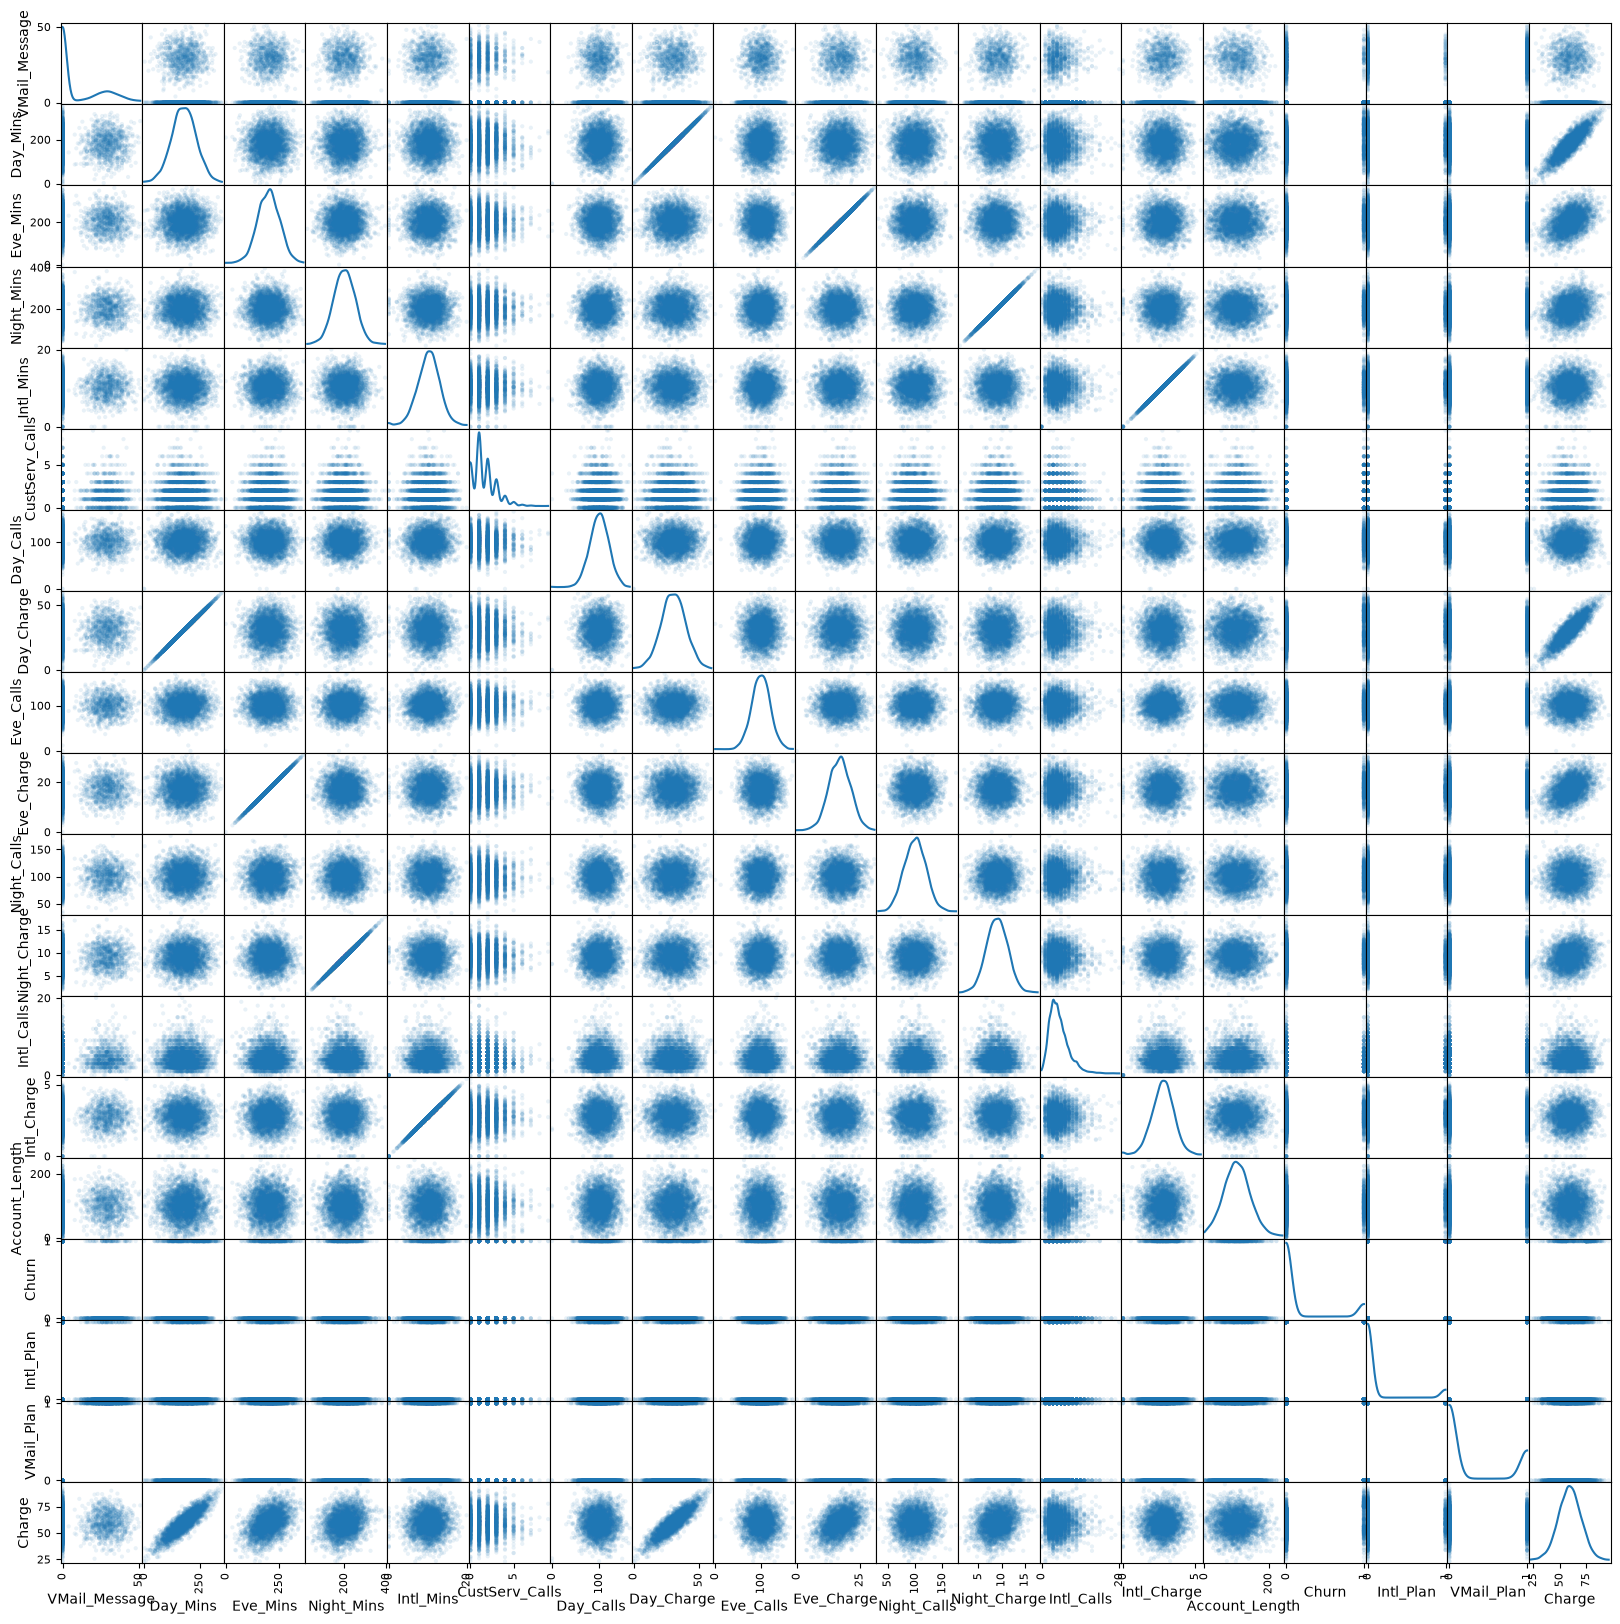

In [9]:
pd.plotting.scatter_matrix(dfw_num, alpha=0.1, figsize=(20, 20), diagonal = 'kde')
plt.show()

## Paso 7.

Ahora procederemos a segmentar a los usuarios. Para ello utilizaremos Kmeans que es una técnica de clústering que se cataloga dentro de los algoritmos de entrenamiento no supervisado.

Probaremos segmentar a los usuarios de 3 a 8 clústeres y nos quedaremos con el mejor resultado atendiendo a la métrica de Silueta.

In [10]:
dfw_State = pd.get_dummies(dfw['State'])
dfw_Area_Code = pd.get_dummies(dfw['Area_Code'])

dfw = pd.concat([dfw, dfw_State], axis=1)
dfw = pd.concat([dfw, dfw_Area_Code], axis=1)

X = dfw.drop(columns=['Churn', 'State', 'Area_Code', 'Phone', 'Day_Charge', 'Eve_Charge', 'Night_Charge', 'Intl_Charge'])
print("Tras las operaciones de Ingeniería de características el tamaño de la base de datos resultante es: ", X.shape)

range_n_clusters =[3, 4, 5, 6, 7, 8, 9, 10]

for n_cluster in range_n_clusters:
  kmeans = KMeans(n_clusters=n_cluster, random_state=0).fit_predict(X)
  silhouette = silhouette_score(X, kmeans, metric='euclidean', sample_size=None, random_state=0)
  print("Para {0} clusteres el valor promedio de Silhouette Score es: {1}.".format(n_cluster, silhouette))

Tras las operaciones de Ingeniería de características el tamaño de la base de datos resultante es:  (3333, 68)
Para 3 clusteres el valor promedio de Silhouette Score es: 0.14698236881569013.
Para 4 clusteres el valor promedio de Silhouette Score es: 0.14329648664009467.
Para 5 clusteres el valor promedio de Silhouette Score es: 0.13880102519942347.
Para 6 clusteres el valor promedio de Silhouette Score es: 0.1355561890495432.
Para 7 clusteres el valor promedio de Silhouette Score es: 0.13135112963878584.
Para 8 clusteres el valor promedio de Silhouette Score es: 0.13046316272333044.
Para 9 clusteres el valor promedio de Silhouette Score es: 0.13027373565500217.
Para 10 clusteres el valor promedio de Silhouette Score es: 0.13091531283048402.


El valor de Silueta más alto se obtiene para tres clústeres por lo que se procederá a utilizar ese número.

## Paso 8.

Como el dataset contiene datos de usuarios, en muchas ocaciones es conveniente, por el reglamento de protección de datos, que los datos estén anonimizados.

Una técnica interesante para anonimizar datos el el análisis de componentes principales (PCA). Este análisis permite reducir la dimensionalidad del problema con el añadido de que permite anonimizar el dataset, ya que crea features nuevas a partir de las features originales.

La aplicación de este algoritmo va en contra de la explicabilidad de los modelos, por lo que no se debería utilizar si la explicabilidad en imprescindible.

In [11]:
n_components = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
exp_var = []

for n in n_components:
  pca = PCA(n, svd_solver='full').fit(X)
  a = sum(pca.explained_variance_ratio_)
  b = pca.explained_variance_ratio_
  row = [n, a]
  exp_var.append(row)
  print("El porcentaje de Variabilidad Explicada para {0} componentes es {1}".format(n, a))
print("El porcentaje de Variabilidad Explicada de cada componente es: {0}".format(b))

El porcentaje de Variabilidad Explicada para 1 componentes es 0.27392628813953646
El porcentaje de Variabilidad Explicada para 2 componentes es 0.5065916601642323
El porcentaje de Variabilidad Explicada para 3 componentes es 0.7341594782120187
El porcentaje de Variabilidad Explicada para 4 componentes es 0.8760399053930017
El porcentaje de Variabilidad Explicada para 5 componentes es 0.9122013916060462
El porcentaje de Variabilidad Explicada para 6 componentes es 0.9477244664875706
El porcentaje de Variabilidad Explicada para 7 componentes es 0.9816420324503172
El porcentaje de Variabilidad Explicada para 8 componentes es 0.9984062318384908
El porcentaje de Variabilidad Explicada para 9 componentes es 0.9991535763771162
El porcentaje de Variabilidad Explicada para 10 componentes es 0.9996929039387694
El porcentaje de Variabilidad Explicada de cada componente es: [0.27392629 0.23266537 0.22756782 0.14188043 0.03616149 0.03552307
 0.03391757 0.0167642  0.00074734 0.00053933]


<Axes: xlabel='N. Componentes', ylabel='Variabilidad Explicada'>

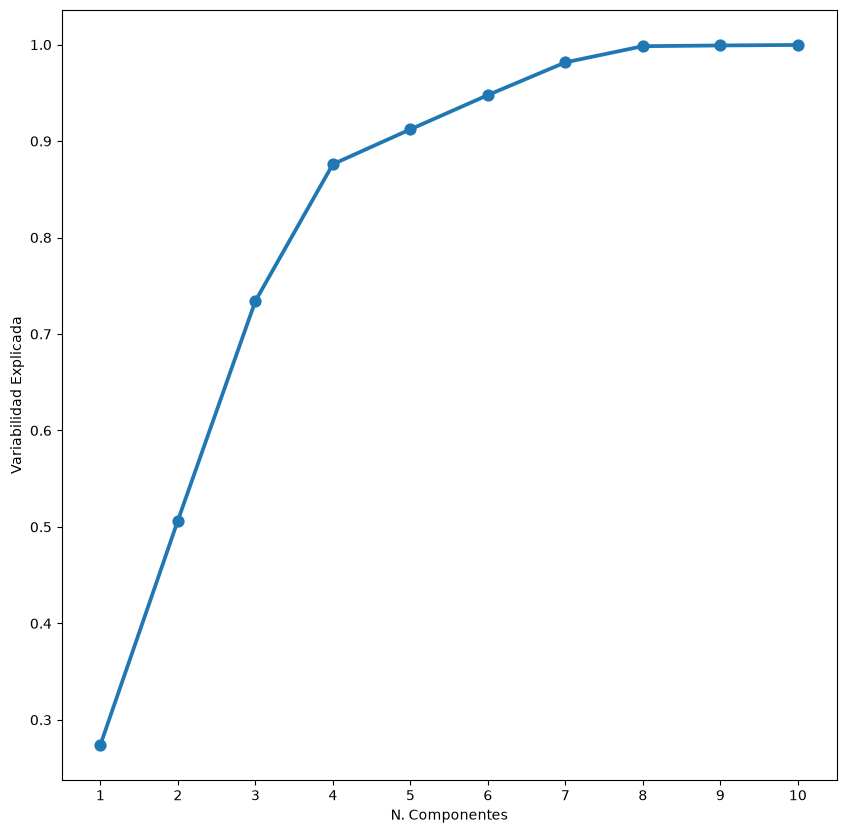

In [12]:
VAR = pd.DataFrame(exp_var, columns=['N. Componentes', 'Variabilidad Explicada'])

fig, ax = plt.subplots(figsize=(10,10))
sb.pointplot(data=VAR, x="N. Componentes", y="Variabilidad Explicada", dodge=False)

In [13]:
pd.DataFrame(
    data    = pca.components_,
    columns = X.columns,
    index   = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10']
)

,VMail_Message,Day_Mins,Eve_Mins,Night_Mins,Intl_Mins,CustServ_Calls,Day_Calls,Eve_Calls,Night_Calls,Intl_Calls,...,UT,VA,VT,WA,WI,WV,WY,408,415,510
PC1,0.000868,0.975646,0.114573,0.055871,-0.000495,-0.000368,0.002368,0.005908,0.009780,0.000346,...,0.000017,-0.000010,2.318272e-05,-0.000005,-0.000010,-0.000078,0.000007,-0.000221,0.000303,-0.000082
PC2,0.002988,-0.071585,0.828650,-0.553950,0.000014,-0.000119,-0.014369,-0.004376,-0.000611,0.000398,...,0.000007,-0.000035,9.929373e-07,0.000022,-0.000017,-0.000125,0.000044,0.000129,-0.000198,0.000069
PC3,0.004709,-0.122245,0.541184,0.829211,-0.000933,-0.000346,0.002709,-0.004814,0.005008,-0.000502,...,-0.000103,0.000109,6.163501e-05,0.000007,-0.000029,-0.000074,0.000010,-0.000094,0.000115,-0.000021
PC4,-0.001676,-0.010477,0.015340,0.018637,0.000668,-0.000141,0.026065,0.012544,-0.008608,0.001268,...,-0.000007,0.000078,4.805193e-05,0.000012,-0.000035,-0.000114,0.000069,0.000130,0.000002,-0.000132
PC5,-0.014334,-0.000794,0.010896,-0.008566,0.003540,-0.000883,0.941328,0.131465,-0.308816,0.000683,...,-0.000096,0.000345,-3.824375e-05,-0.000033,-0.000213,0.000217,0.000053,0.000215,0.000094,-0.000309
PC6,-0.004228,-0.008306,0.003893,0.000498,0.000566,0.000057,-0.060072,0.970910,0.231384,0.002024,...,-0.000102,-0.000096,-1.233195e-04,-0.000180,-0.000014,-0.000164,-0.000031,-0.000349,0.000526,-0.000177
PC7,0.005985,-0.007921,-0.000795,-0.008282,-0.000948,-0.001244,0.330534,-0.199389,0.922394,-0.000193,...,0.000027,-0.000195,5.679542e-05,0.000193,-0.000048,0.000167,0.000155,-0.000575,0.000280,0.000295
PC8,0.999359,-0.000108,-0.004942,-0.002346,0.000821,-0.001270,0.011336,0.007233,-0.009026,0.002667,...,0.000048,-0.000123,-1.880853e-04,-0.000380,0.000019,0.000119,-0.000197,-0.000564,0.000689,-0.000125
PC9,-0.001032,-0.042176,-0.020759,-0.010356,0.961912,-0.006370,-0.003157,-0.001471,0.001900,0.097824,...,0.000019,0.001080,-1.676525e-04,-0.001074,-0.001489,-0.000735,0.000580,-0.003887,0.007359,-0.003472
PC10,-0.002542,0.003797,0.001917,0.001620,-0.094721,-0.012077,-0.000225,-0.001999,-0.000245,0.995060,...,0.000523,0.000868,4.933855e-04,0.000117,-0.001147,-0.000177,0.001830,-0.001817,0.006133,-0.004315


In [14]:
pca8 = PCA(8, svd_solver='full').fit(X)

dfwt =pd.DataFrame(pca8.transform(X), columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8'])
dfwt

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,88.290550,-32.966807,24.369748,27.073784,10.186573,-4.790313,-5.931778,17.028536
1,-15.251265,-33.200849,43.624164,7.604251,19.805701,2.143410,9.373042,18.074457
2,51.685205,-49.731792,-83.443464,33.763907,11.364158,8.544070,5.993838,-7.382809
3,101.484238,-120.860622,-92.413465,-21.316911,-26.839095,-13.920326,-18.458191,-7.761810
4,-20.716857,-35.466155,-38.307200,-26.545541,8.665599,25.492787,19.236623,-7.733071
...,...,...,...,...,...,...,...,...
3328,-16.233791,-29.523761,73.227019,92.606059,-16.896477,21.958383,-28.819956,27.853137
3329,44.421334,-36.790201,-38.702474,-36.364911,-53.290659,-36.191716,15.343370,-8.923817
3330,11.177430,78.187605,42.445747,-72.041088,8.624701,-42.508031,2.613218,-8.734087
3331,25.545463,-2.892202,-79.651468,80.343056,-11.464159,-8.543236,39.143679,-8.034389


## Paso 9.

Volveremos a realizar el análisis pero sobre las componentes principales. Los resultados deberían ser similares ya que 8 componentes explican el 99,8% de la variabilidad de las variables originales.

In [15]:
Xt = dfwt

range_n_clusters =[3, 4, 5, 6, 7, 8, 9, 10]

for n_cluster in range_n_clusters:
  kmeanst = KMeans(n_clusters=n_cluster, random_state=0).fit_predict(Xt)
  silhouette = silhouette_score(X, kmeanst, metric='euclidean', sample_size=None, random_state=0)
  print("Para {0} clusteres el valor promedio de Silhouette Score es: {1}.".format(n_cluster, silhouette))

Para 3 clusteres el valor promedio de Silhouette Score es: 0.14693926968084667.
Para 4 clusteres el valor promedio de Silhouette Score es: 0.14384299385723393.
Para 5 clusteres el valor promedio de Silhouette Score es: 0.1387994585704239.
Para 6 clusteres el valor promedio de Silhouette Score es: 0.13399131516649793.
Para 7 clusteres el valor promedio de Silhouette Score es: 0.1305025176939763.
Para 8 clusteres el valor promedio de Silhouette Score es: 0.12786828089373656.
Para 9 clusteres el valor promedio de Silhouette Score es: 0.12809769185236783.
Para 10 clusteres el valor promedio de Silhouette Score es: 0.1286125039704442.


In [16]:
kmeansf = KMeans(n_clusters=3, random_state=0).fit_predict(Xt)

dfwf = dfw
dfwtf = dfwt

dfwf['Cluster'] = pd.Series(kmeansf, index=dfw.index)
dfwtf['Cluster'] = pd.Series(kmeansf, index=dfwt.index)
dfwf['Cluster'] = dfwf['Cluster'].astype(str)
dfwtf['Cluster'] = dfwtf['Cluster'].astype(str)

print(dfwf)
print(dfwtf)

      VMail_Message  Day_Mins  Eve_Mins  Night_Mins  Intl_Mins  \
0                25     265.1     197.4       244.7       10.0   
1                26     161.6     195.5       254.4       13.7   
2                 0     243.4     121.2       162.6       12.2   
3                 0     299.4      61.9       196.9        6.6   
4                 0     166.7     148.3       186.9       10.1   
...             ...       ...       ...         ...        ...   
3328             36     156.2     215.5       279.1        9.9   
3329              0     231.1     153.4       191.3        9.6   
3330              0     180.8     288.8       191.9       14.1   
3331              0     213.8     159.6       139.2        5.0   
3332             25     234.4     265.9       241.4       13.7   

      CustServ_Calls  Day_Calls  Day_Charge  Eve_Calls  Eve_Charge  ...  \
0                  1        110       45.07         99       16.78  ...   
1                  1        123       27.47        103   

<Axes: xlabel='Day_Mins', ylabel='Night_Mins'>

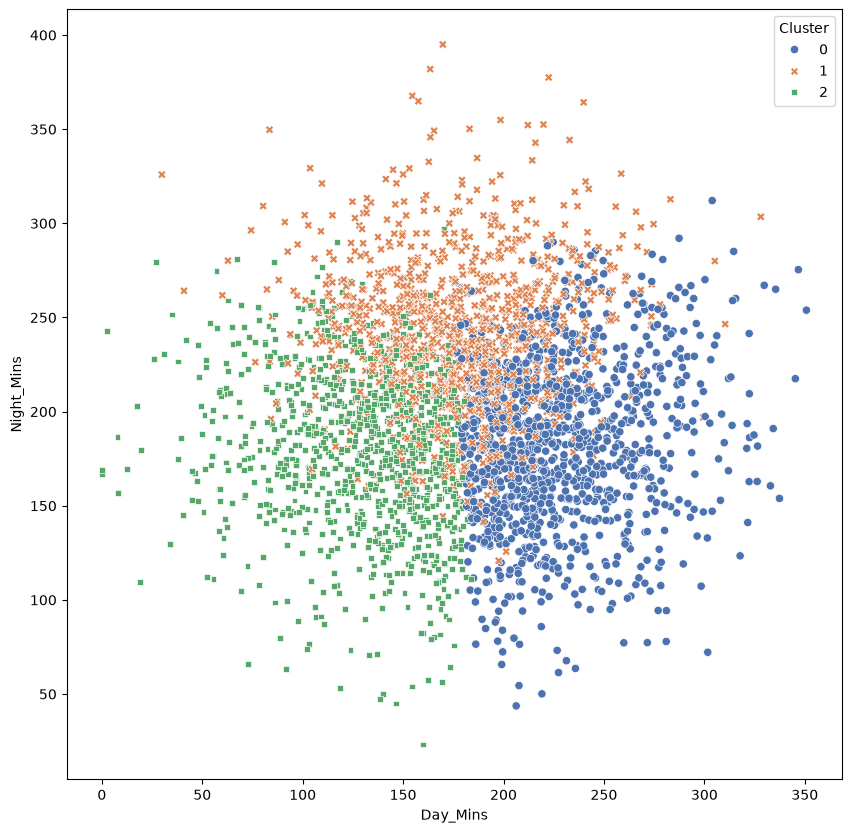

In [17]:
fig, ax = plt.subplots(figsize=(10,10))
sb.scatterplot(x="Day_Mins", y="Night_Mins", hue="Cluster", style="Cluster", data=dfw, ax=ax, palette="deep")

In [18]:
fig = px.scatter(dfwt, x="PC1", y="PC2", color="Cluster", symbol="Cluster")
fig.update_layout(height=700, width=700)
fig.show()